Trash detection Computer Vision Model

In [11]:
import subprocess
subprocess.run(['fusermount', '-u', '/content/drive'], capture_output=True)
subprocess.run(['rm', '-rf', '/content/drive'], capture_output=True)

from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


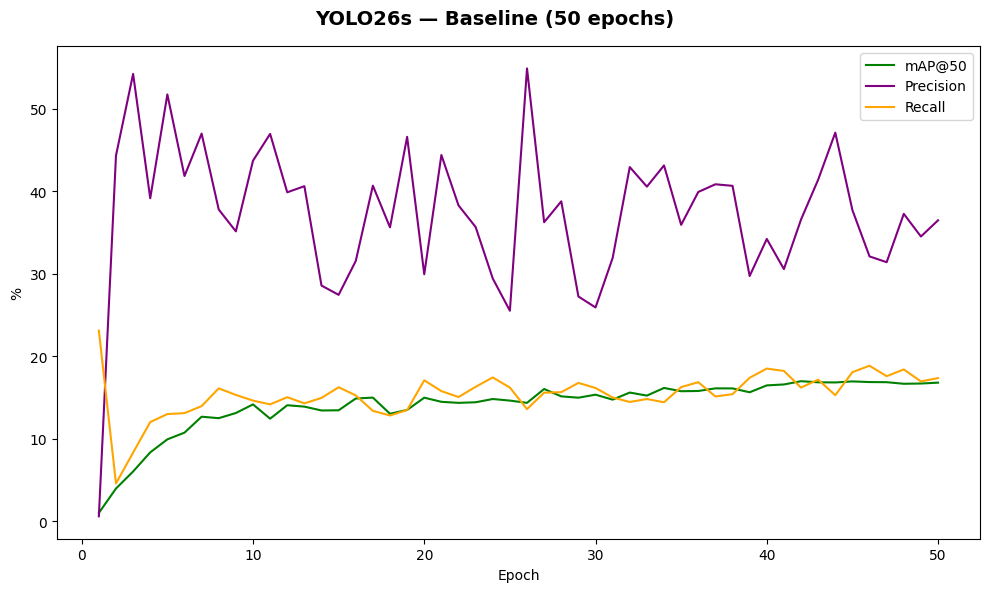

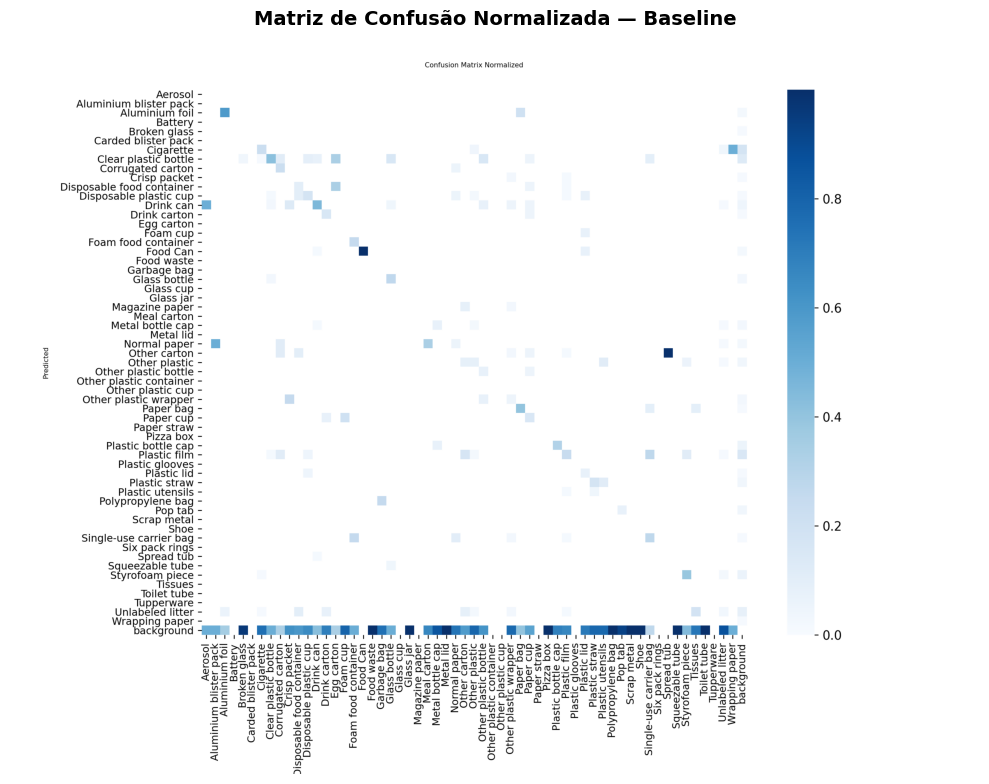


📊 RESULTADOS FINAIS — Baseline (50 epochs)
  mAP@50:      16.81%
  mAP@50:95:   13.99%
  Precision:   36.49%
  Recall:      17.36%


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

# ── BASELINE (50 epochs) ───────────────────────────────────
base = '/content/drive/MyDrive/VisaoComputacional/resultados/trash_baseline'
df = pd.read_csv(f'{base}/results.csv')
df.columns = df.columns.str.strip()

# Gráfico comparação geral
fig, ax = plt.subplots(figsize=(10, 6))
fig.suptitle('YOLO26s — Baseline (50 epochs)', fontsize=14, fontweight='bold')
ax.plot(df['epoch'], df['metrics/mAP50(B)'] * 100, color='green', label='mAP@50')
ax.plot(df['epoch'], df['metrics/precision(B)'] * 100, color='purple', label='Precision')
ax.plot(df['epoch'], df['metrics/recall(B)'] * 100, color='orange', label='Recall')
ax.set_ylabel('%')
ax.set_xlabel('Epoch')
ax.legend()
plt.tight_layout()
plt.savefig(f'{base}/comparacao_baseline.png', dpi=150, bbox_inches='tight')
plt.show()

# Matriz de confusão (só normalizada)
fig, ax = plt.subplots(figsize=(10, 8))
fig.suptitle('Matriz de Confusão Normalizada — Baseline', fontsize=14, fontweight='bold')
img = Image.open(f'{base}/confusion_matrix_normalized.png')
ax.imshow(img); ax.axis('off')
plt.tight_layout()
plt.savefig(f'{base}/matriz_confusao_baseline.png', dpi=150, bbox_inches='tight')
plt.show()

# Métricas finais
ultimo = df.iloc[-1]
print("\n📊 RESULTADOS FINAIS — Baseline (50 epochs)")
print(f"  mAP@50:      {ultimo['metrics/mAP50(B)'] * 100:.2f}%")
print(f"  mAP@50:95:   {ultimo['metrics/mAP50-95(B)'] * 100:.2f}%")
print(f"  Precision:   {ultimo['metrics/precision(B)'] * 100:.2f}%")
print(f"  Recall:      {ultimo['metrics/recall(B)'] * 100:.2f}%")

In [ ]:
import subprocess, os

os.makedirs('/content/drive/MyDrive/VisaoComputacional/resultados', exist_ok=True)

subprocess.run([
    'scp', '-P', '4422', '-r',
    'vfdabreu@sc2.npad.ufrn.br:/home/vfdabreu/resultados/trash_v2_100ep',
    '/content/drive/MyDrive/VisaoComputacional/resultados/'
])

print("✅ Resultados baixados!")

✅ Resultados baixados!


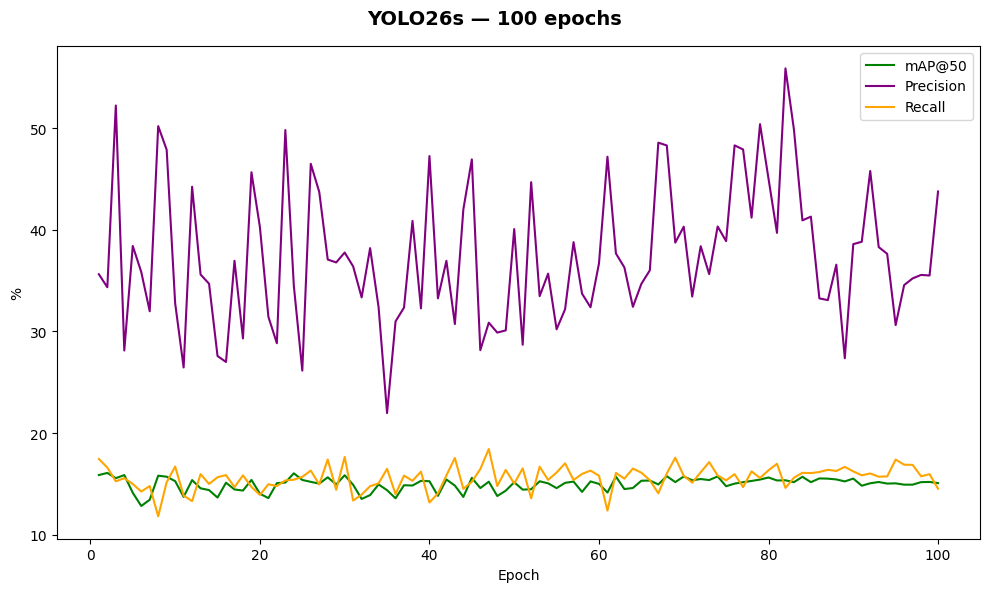

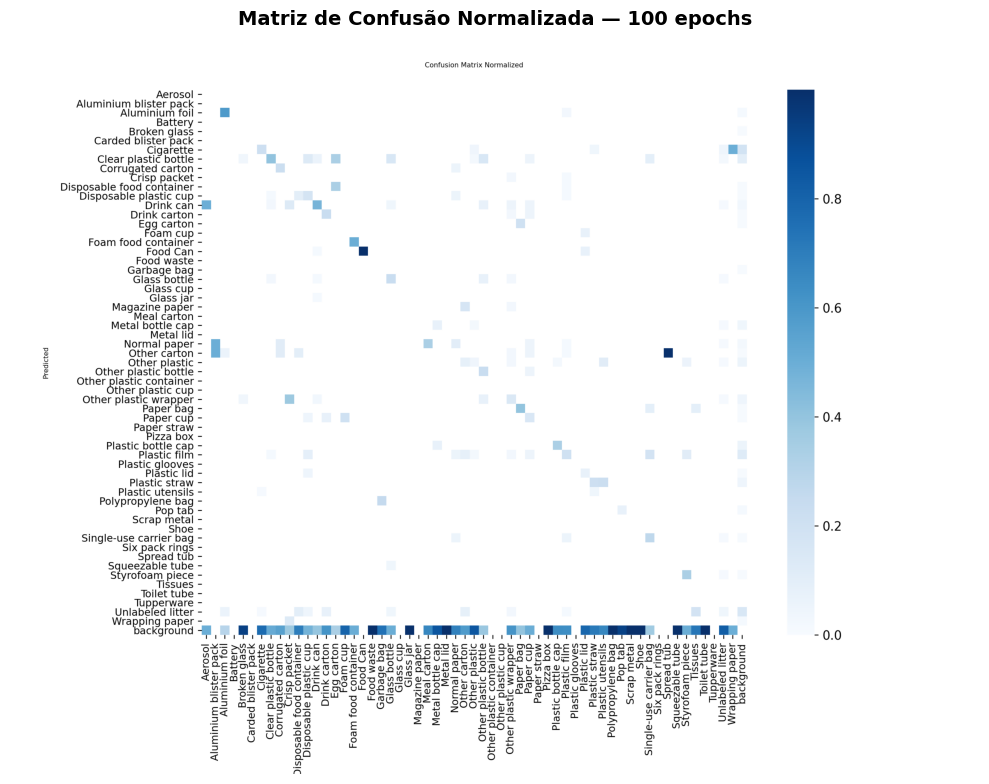


📊 RESULTADOS FINAIS — 100 epochs
  mAP@50:      15.07%
  mAP@50:95:   12.62%
  Precision:   43.78%
  Recall:      14.52%


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

base = '/content/drive/MyDrive/VisaoComputacional/resultados/trash_v2_100ep'
df = pd.read_csv(f'{base}/results.csv')
df.columns = df.columns.str.strip()

# Gráfico comparação geral
fig, ax = plt.subplots(figsize=(10, 6))
fig.suptitle('YOLO26s — 100 epochs', fontsize=14, fontweight='bold')
ax.plot(df['epoch'], df['metrics/mAP50(B)'] * 100, color='green', label='mAP@50')
ax.plot(df['epoch'], df['metrics/precision(B)'] * 100, color='purple', label='Precision')
ax.plot(df['epoch'], df['metrics/recall(B)'] * 100, color='orange', label='Recall')
ax.set_ylabel('%')
ax.set_xlabel('Epoch')
ax.legend()
plt.tight_layout()
plt.savefig(f'{base}/comparacao_100ep.png', dpi=150, bbox_inches='tight')
plt.show()

# Matriz de confusão (só normalizada)
fig, ax = plt.subplots(figsize=(10, 8))
fig.suptitle('Matriz de Confusão Normalizada — 100 epochs', fontsize=14, fontweight='bold')
img = Image.open(f'{base}/confusion_matrix_normalized.png')
ax.imshow(img); ax.axis('off')
plt.tight_layout()
plt.savefig(f'{base}/matriz_confusao_100ep.png', dpi=150, bbox_inches='tight')
plt.show()

# Métricas finais
ultimo = df.iloc[-1]
print("\n📊 RESULTADOS FINAIS — 100 epochs")
print(f"  mAP@50:      {ultimo['metrics/mAP50(B)'] * 100:.2f}%")
print(f"  mAP@50:95:   {ultimo['metrics/mAP50-95(B)'] * 100:.2f}%")
print(f"  Precision:   {ultimo['metrics/precision(B)'] * 100:.2f}%")
print(f"  Recall:      {ultimo['metrics/recall(B)'] * 100:.2f}%")

In [ ]:
import subprocess, os

subprocess.run([
    'scp', '-P', '4422',
    'vfdabreu@sc2.npad.ufrn.br:/home/vfdabreu/resultados/trash_rfdetr/confusion_matrix_rfdetr.png',
    '/content/drive/MyDrive/VisaoComputacional/resultados/trash_rfdetr/'
])

print("✅ Matriz baixada!")

✅ Matriz baixada!


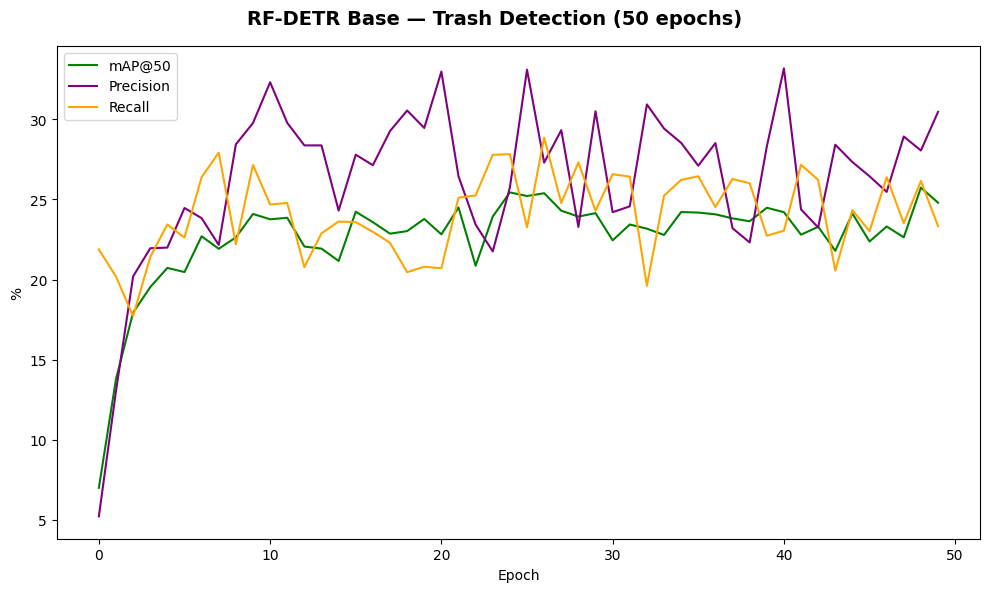

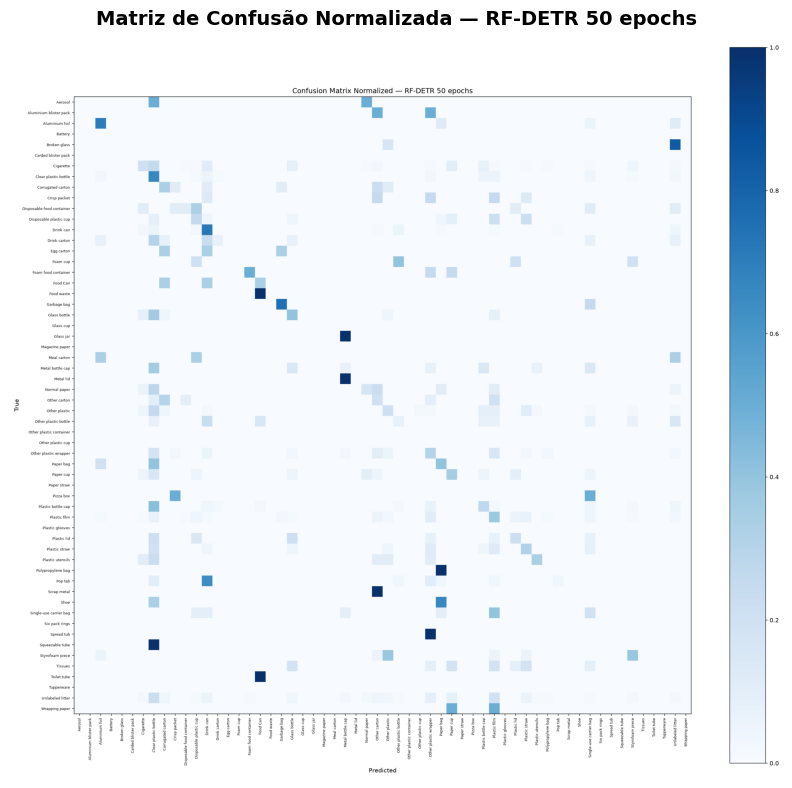


📊 MELHORES RESULTADOS RF-DETR 50 epochs (epoch 48)
  mAP@50:      25.74%
  mAP@50:95:   20.96%
  Precision:   28.06%
  Recall:      26.16%


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

base = '/content/drive/MyDrive/VisaoComputacional/resultados/trash_rfdetr'
df = pd.read_csv(f'{base}/metrics.csv')

# Filtra só as linhas de validação
val = df.dropna(subset=['val/mAP_50']).reset_index(drop=True)

# Gráfico comparação geral
fig, ax = plt.subplots(figsize=(10, 6))
fig.suptitle('RF-DETR Base — Trash Detection (50 epochs)', fontsize=14, fontweight='bold')
ax.plot(val['epoch'], val['val/mAP_50'] * 100, color='green', label='mAP@50')
ax.plot(val['epoch'], val['val/precision'] * 100, color='purple', label='Precision')
ax.plot(val['epoch'], val['val/recall'] * 100, color='orange', label='Recall')
ax.set_ylabel('%')
ax.set_xlabel('Epoch')
ax.legend()
plt.tight_layout()
plt.savefig(f'{base}/comparacao_rfdetr_50ep.png', dpi=150, bbox_inches='tight')
plt.show()

# Matriz de confusão RF-DETR
from PIL import Image

fig, ax = plt.subplots(figsize=(10, 8))
fig.suptitle('Matriz de Confusão Normalizada — RF-DETR 50 epochs', fontsize=14, fontweight='bold')
img = Image.open(f'{base}/confusion_matrix_rfdetr.png')
ax.imshow(img); ax.axis('off')
plt.tight_layout()
plt.savefig(f'{base}/matriz_confusao_rfdetr_50ep.png', dpi=150, bbox_inches='tight')
plt.show()

# Métricas finais
melhor = val.loc[val['val/mAP_50'].idxmax()]
print(f"\n📊 MELHORES RESULTADOS RF-DETR 50 epochs (epoch {int(melhor['epoch'])})")
print(f"  mAP@50:      {melhor['val/mAP_50'] * 100:.2f}%")
print(f"  mAP@50:95:   {melhor['val/mAP_50_95'] * 100:.2f}%")
print(f"  Precision:   {melhor['val/precision'] * 100:.2f}%")
print(f"  Recall:      {melhor['val/recall'] * 100:.2f}%")

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import matplotlib.image as mpimg

# Classes para remover (completamente em branco)
classes_remover = [
    'Aerosol', 'Aluminium blister pack', 'Battery', 'Carded blister pack',
    'Egg carton', 'Foam cup', 'Food waste', 'Glass cup', 'Magazine paper',
    'Meal carton', 'Other plastic container', 'Other plastic cup', 'Pizza box',
    'Plastic glooves', 'Polypropylene bag', 'Shoe', 'Six pack rings',
    'Spread tub', 'Tissues', 'Toilet tube', 'Tupperware', 'Wrapping paper'
]

# Carrega a imagem da matriz original do RF-DETR
# Como já temos a imagem gerada, vamos gerar uma nova matriz filtrada no NPAD
print("Classes a remover:", len(classes_remover))
print("Classes restantes:", 58 - len(classes_remover))

Classes a remover: 22
Classes restantes: 36


In [ ]:
import subprocess

subprocess.run([
    'scp', '-P', '4422',
    'vfdabreu@sc2.npad.ufrn.br:/home/vfdabreu/resultados/trash_rfdetr/confusion_matrix_rfdetr_filtrada.png',
    '/content/drive/MyDrive/VisaoComputacional/resultados/trash_rfdetr/'
])

print("✅ Matriz filtrada baixada!")

✅ Matriz filtrada baixada!


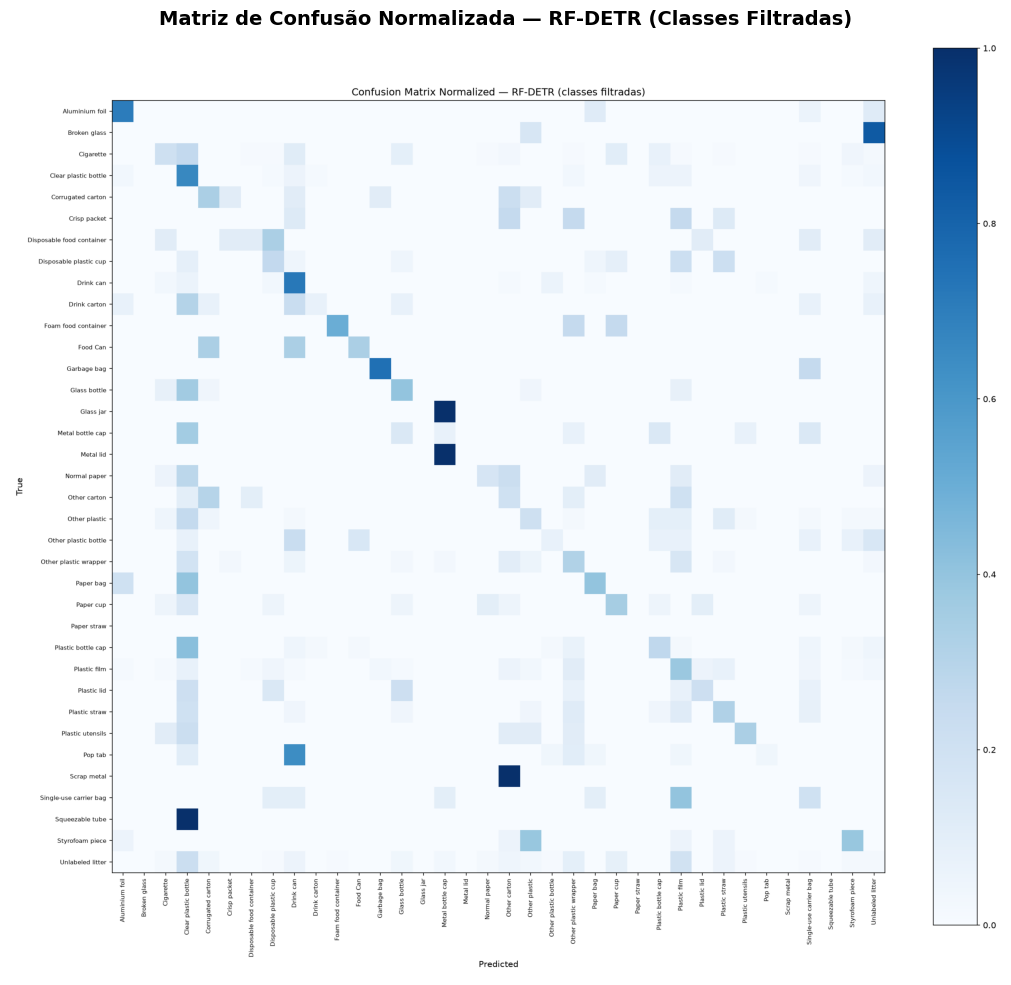

In [ ]:
import matplotlib.pyplot as plt
from PIL import Image

base = '/content/drive/MyDrive/VisaoComputacional/resultados/trash_rfdetr'

fig, ax = plt.subplots(figsize=(12, 10))
fig.suptitle('Matriz de Confusão Normalizada — RF-DETR (Classes Filtradas)', fontsize=14, fontweight='bold')
img = Image.open(f'{base}/confusion_matrix_rfdetr_filtrada.png')
ax.imshow(img)
ax.axis('off')
plt.tight_layout()
plt.savefig(f'{base}/matriz_confusao_rfdetr_filtrada.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
import subprocess

subprocess.run([
    'scp', '-P', '4422',
    'vfdabreu@sc2.npad.ufrn.br:/home/vfdabreu/resultados/trash_baseline/confusion_matrix_yolo_filtrada.png',
    '/content/drive/MyDrive/VisaoComputacional/resultados/trash_baseline/'
])

print("✅ Matriz YOLO filtrada baixada!")

✅ Matriz YOLO filtrada baixada!


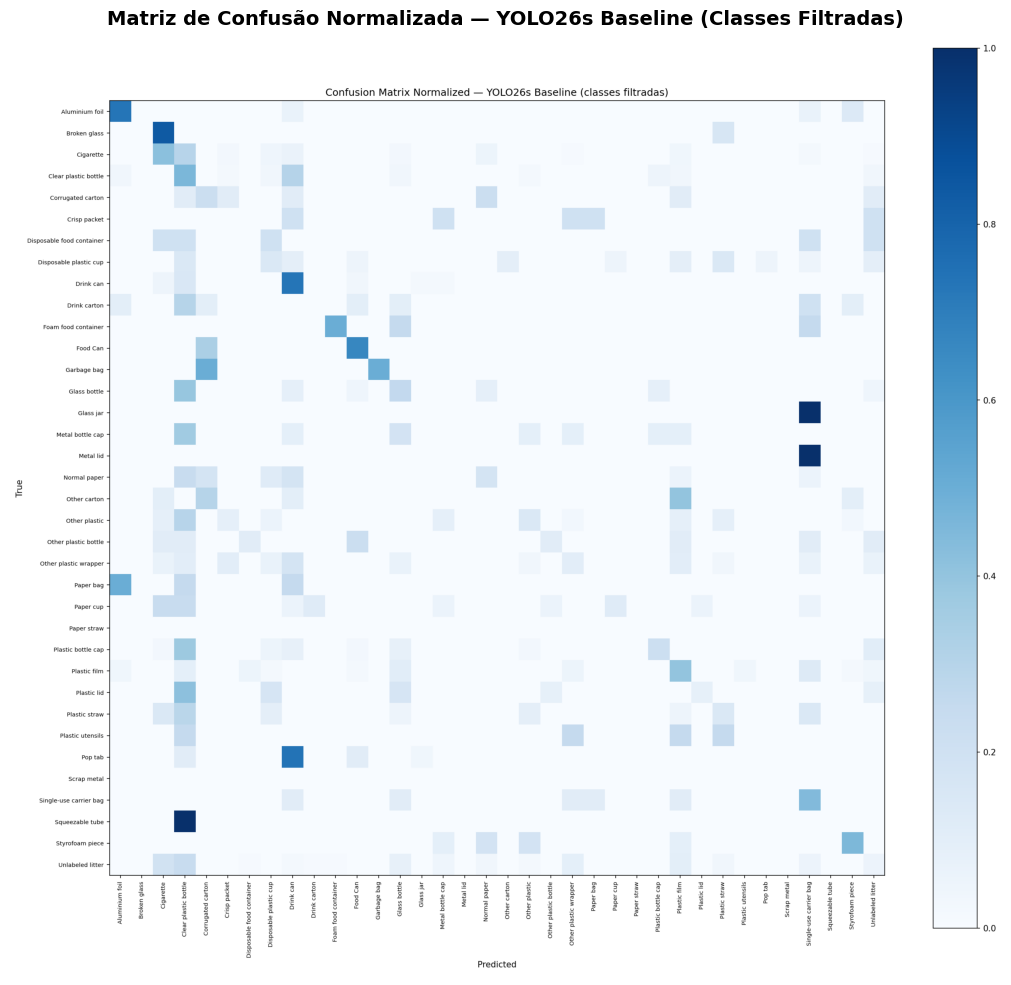

In [ ]:
import matplotlib.pyplot as plt
from PIL import Image

base = '/content/drive/MyDrive/VisaoComputacional/resultados/trash_baseline'

fig, ax = plt.subplots(figsize=(12, 10))
fig.suptitle('Matriz de Confusão Normalizada — YOLO26s Baseline (Classes Filtradas)',
             fontsize=14, fontweight='bold')
img = Image.open(f'{base}/confusion_matrix_yolo_filtrada.png')
ax.imshow(img); ax.axis('off')
plt.tight_layout()
plt.savefig(f'{base}/matriz_confusao_yolo_filtrada.png', dpi=150, bbox_inches='tight')
plt.show()